In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torchvision import models, transforms
from torchvision.models import DenseNet121_Weights

In [3]:
DATA_ROOT = Path("./two_class_cifar")
OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
image_paths = []
labels = []

for label_dir in ["cat", "dog"]:
    folder = DATA_ROOT / label_dir
    for img_path in sorted(folder.glob("*.png")):
        image_paths.append(img_path)
        labels.append(label_dir)

print("Total images:", len(image_paths))
print(pd.Series(labels).value_counts())

Total images: 40
cat    20
dog    20
Name: count, dtype: int64


In [5]:
weights = DenseNet121_Weights.DEFAULT
densenet = models.densenet121(weights=weights)
densenet = densenet.to(device)
densenet.eval()

# 官方推荐的预处理
preprocess = weights.transforms()

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /home/amyliu/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 72.1MB/s]


In [6]:
class DenseNetFeatureExtractor(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.features = model.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = self.features(x)
        x = torch.relu(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)   # shape: (B, 1024)
        return x

feature_extractor = DenseNetFeatureExtractor(densenet).to(device)
feature_extractor.eval()

DenseNetFeatureExtractor(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

In [7]:
densenet_embeddings = []
metadata_rows = []

with torch.no_grad():
    for img_path, label in tqdm(list(zip(image_paths, labels)), total=len(image_paths)):
        image = Image.open(img_path).convert("RGB")
        img_tensor = preprocess(image).unsqueeze(0).to(device)

        feat = feature_extractor(img_tensor)     # (1, 1024)
        feat = feat.squeeze(0).cpu().numpy()     # (1024,)

        densenet_embeddings.append(feat)
        metadata_rows.append({
            "filename": img_path.name,
            "label": label,
            "path": str(img_path)
        })

densenet_embeddings = np.array(densenet_embeddings)
metadata_df = pd.DataFrame(metadata_rows)

print("Embedding shape:", densenet_embeddings.shape)
print(metadata_df.head())

100%|██████████| 40/40 [00:00<00:00, 101.59it/s]

Embedding shape: (40, 1024)
      filename label                             path
0  cat_000.png   cat  two_class_cifar/cat/cat_000.png
1  cat_001.png   cat  two_class_cifar/cat/cat_001.png
2  cat_002.png   cat  two_class_cifar/cat/cat_002.png
3  cat_003.png   cat  two_class_cifar/cat/cat_003.png
4  cat_004.png   cat  two_class_cifar/cat/cat_004.png


In [8]:
np.save(OUTPUT_DIR / "densenet_embeddings_cat_dog.npy", densenet_embeddings)
metadata_df.to_csv(OUTPUT_DIR / "densenet_metadata_cat_dog.csv", index=False)

print("Saved:", OUTPUT_DIR / "densenet_embeddings_cat_dog.npy")
print("Saved:", OUTPUT_DIR / "densenet_metadata_cat_dog.csv")

Saved: outputs/densenet_embeddings_cat_dog.npy
Saved: outputs/densenet_metadata_cat_dog.csv


In [9]:
from sklearn.metrics.pairwise import cosine_similarity

embeddings = np.load(OUTPUT_DIR / "densenet_embeddings_cat_dog.npy")
meta = pd.read_csv(OUTPUT_DIR / "densenet_metadata_cat_dog.csv")

sim_matrix = cosine_similarity(embeddings)
n = len(meta)

all_sims = []
pair_rows = []

for i in range(n):
    for j in range(i + 1, n):
        sim = sim_matrix[i, j]

        all_sims.append(sim)
        pair_rows.append({
            "idx1": i,
            "idx2": j,
            "file1": meta.loc[i, "filename"],
            "file2": meta.loc[j, "filename"],
            "label1": meta.loc[i, "label"],
            "label2": meta.loc[j, "label"],
            "cosine_similarity": sim
        })

all_sims = np.array(all_sims)
pair_df = pd.DataFrame(pair_rows)

pair_df.to_csv(OUTPUT_DIR / "densenet_pairwise_similarity.csv", index=False)

print("Total pairs:", len(all_sims))
print("Mean cosine similarity:", all_sims.mean())
print("Saved:", OUTPUT_DIR / "densenet_pairwise_similarity.csv")

Total pairs: 780
Mean cosine similarity: 0.6752084
Saved: outputs/densenet_pairwise_similarity.csv


In [10]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

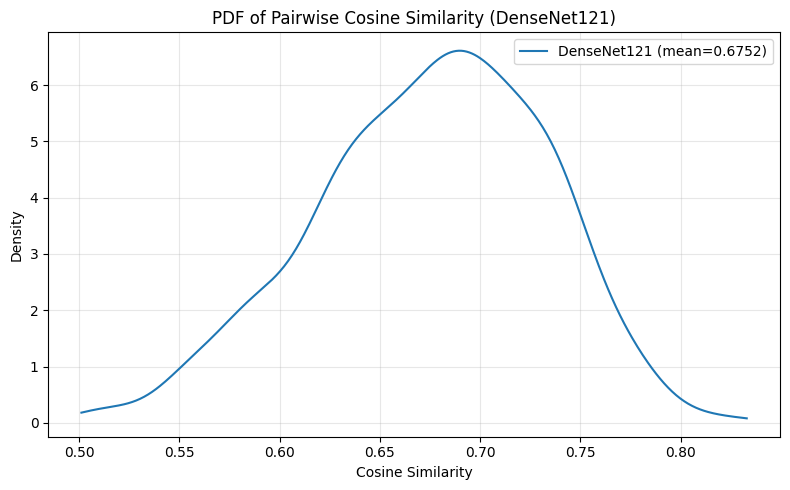

In [11]:
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

x_grid = np.linspace(all_sims.min(), all_sims.max(), 500)
kde = gaussian_kde(all_sims)
pdf = kde(x_grid)

plt.figure(figsize=(8, 5))
plt.plot(x_grid, pdf, label=f"DenseNet121 (mean={all_sims.mean():.4f})")
plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.title("PDF of Pairwise Cosine Similarity (DenseNet121)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(FIG_DIR / "pdf_densenet_all_pairs.png", dpi=300)
plt.show()

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import gaussian_kde

OUTPUT_DIR = Path("./outputs")
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 读取 pairwise similarity
resnet_df = pd.read_csv(OUTPUT_DIR / "resnet_pairwise_similarity.csv")
densenet_df = pd.read_csv(OUTPUT_DIR / "densenet_pairwise_similarity.csv")

resnet_sims = resnet_df["cosine_similarity"].values
densenet_sims = densenet_df["cosine_similarity"].values

print("ResNet pairs:", len(resnet_sims))
print("DenseNet pairs:", len(densenet_sims))

print("ResNet mean:", resnet_sims.mean())
print("DenseNet mean:", densenet_sims.mean())

ResNet pairs: 780
DenseNet pairs: 780
ResNet mean: 0.5205833606282051
DenseNet mean: 0.6752083222564103


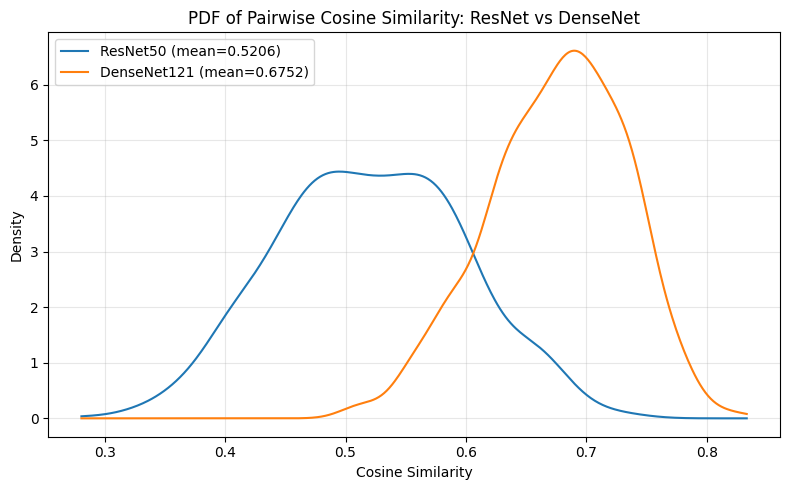

In [13]:
x_min = min(resnet_sims.min(), densenet_sims.min())
x_max = max(resnet_sims.max(), densenet_sims.max())
x_grid = np.linspace(x_min, x_max, 500)

resnet_pdf = gaussian_kde(resnet_sims)(x_grid)
densenet_pdf = gaussian_kde(densenet_sims)(x_grid)

plt.figure(figsize=(8, 5))
plt.plot(x_grid, resnet_pdf, label=f"ResNet50 (mean={resnet_sims.mean():.4f})")
plt.plot(x_grid, densenet_pdf, label=f"DenseNet121 (mean={densenet_sims.mean():.4f})")

plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.title("PDF of Pairwise Cosine Similarity: ResNet vs DenseNet")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(FIG_DIR / "pdf_resnet_vs_densenet.png", dpi=300)
plt.show()

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from pathlib import Path

OUTPUT_DIR = Path("./outputs")

In [15]:
resnet_df = pd.read_csv(OUTPUT_DIR / "resnet_pairwise_similarity.csv")
densenet_df = pd.read_csv(OUTPUT_DIR / "densenet_pairwise_similarity.csv")

In [16]:
resnet_cross = resnet_df[resnet_df["label1"] != resnet_df["label2"]]["cosine_similarity"].values
densenet_cross = densenet_df[densenet_df["label1"] != densenet_df["label2"]]["cosine_similarity"].values

print("ResNet cross mean:", resnet_cross.mean())
print("DenseNet cross mean:", densenet_cross.mean())

ResNet cross mean: 0.513881640325
DenseNet cross mean: 0.6730600106750001


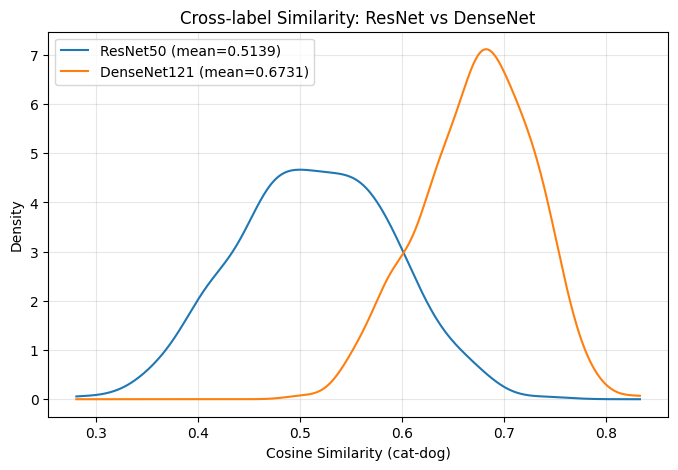

In [17]:
x_min = min(resnet_cross.min(), densenet_cross.min())
x_max = max(resnet_cross.max(), densenet_cross.max())
x_grid = np.linspace(x_min, x_max, 500)

resnet_pdf = gaussian_kde(resnet_cross)(x_grid)
densenet_pdf = gaussian_kde(densenet_cross)(x_grid)

plt.figure(figsize=(8, 5))

plt.plot(x_grid, resnet_pdf, 
         label=f"ResNet50 (mean={resnet_cross.mean():.4f})")

plt.plot(x_grid, densenet_pdf, 
         label=f"DenseNet121 (mean={densenet_cross.mean():.4f})")

plt.xlabel("Cosine Similarity (cat-dog)")
plt.ylabel("Density")
plt.title("Cross-label Similarity: ResNet vs DenseNet")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

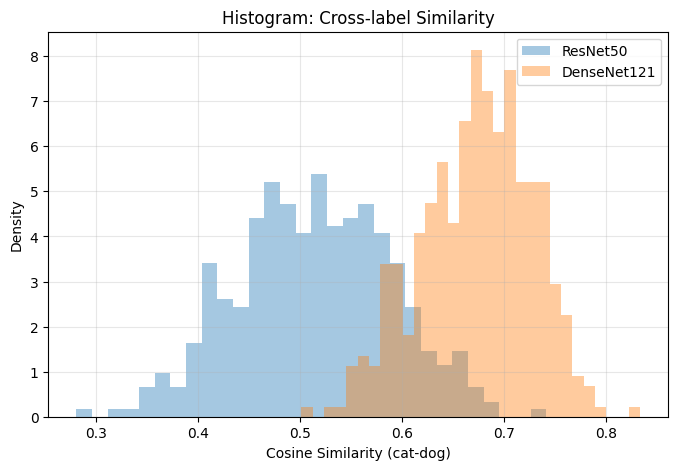

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(resnet_cross, bins=30, density=True, alpha=0.4, label="ResNet50")
plt.hist(densenet_cross, bins=30, density=True, alpha=0.4, label="DenseNet121")

plt.xlabel("Cosine Similarity (cat-dog)")
plt.ylabel("Density")
plt.title("Histogram: Cross-label Similarity")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
resnet_same = resnet_df[resnet_df["label1"] == resnet_df["label2"]]["cosine_similarity"].values
densenet_same = densenet_df[densenet_df["label1"] == densenet_df["label2"]]["cosine_similarity"].values

print("ResNet same mean:", resnet_same.mean())
print("DenseNet same mean:", densenet_same.mean())

ResNet same mean: 0.5276378030526316
DenseNet same mean: 0.677469702868421


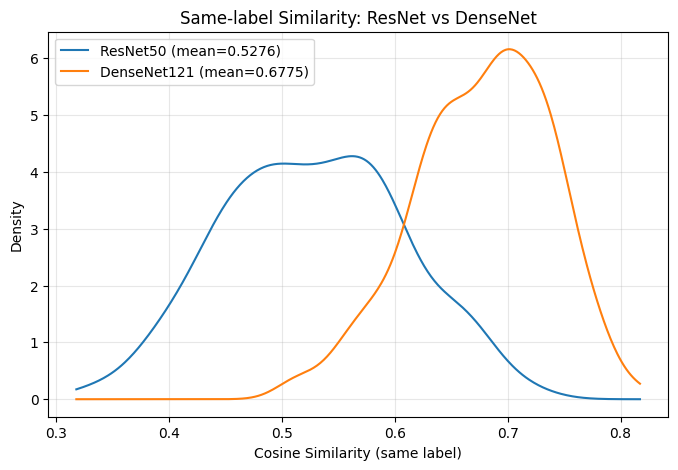

In [20]:
x_min = min(resnet_same.min(), densenet_same.min())
x_max = max(resnet_same.max(), densenet_same.max())
x_grid = np.linspace(x_min, x_max, 500)

resnet_pdf = gaussian_kde(resnet_same)(x_grid)
densenet_pdf = gaussian_kde(densenet_same)(x_grid)

plt.figure(figsize=(8, 5))

plt.plot(x_grid, resnet_pdf, 
         label=f"ResNet50 (mean={resnet_same.mean():.4f})")

plt.plot(x_grid, densenet_pdf, 
         label=f"DenseNet121 (mean={densenet_same.mean():.4f})")

plt.xlabel("Cosine Similarity (same label)")
plt.ylabel("Density")
plt.title("Same-label Similarity: ResNet vs DenseNet")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()